# Wilson-Cowan Model: Critical Transition Prediction

This notebook implements the Wilson-Cowan model exactly as described in the PRX paper (Figure 4).

**Paper's Model**: dx_i/dt = -x_i + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))
- w_ij: edge weights (random between 10-20)
- ε: link degradation control parameter (fraction by which link strengths decrease)
- τ: controls steepness of activation function
- μ: firing-rate threshold
- Network: Erdős-Rényi (ER) with mean degree 3-6, N between 300-700

The model exhibits first-order transitions (explosive collapse) at a critical ε_c.


In [46]:
# Imports and parameters
import numpy as np
import numpy.linalg as npl
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Network parameters (matching paper)
# Paper: N randomly between 300-700, mean degree 3-6
N = 300                 # number of nodes (using fixed value for reproducibility)
mean_degree = 4.5       # mean degree for ER network (between 3-6)
p_er = mean_degree / N  # probability for ER network

# Edge weights (matching paper: random between 10-20)
weight_min = 10.0
weight_max = 20.0

# Model parameters (matching paper)
# Note: Paper doesn't specify exact values, these need to create bistability
# After normalizing weights, we need to tune tau and mu to get transition around ε=0.98
# and have the low-activity branch decrease slightly before transition
tau = 8.0               # τ: controls steepness of activation function
mu = 4.0                # μ: firing-rate threshold (positive threshold helps create bistability)

# Epsilon sweep (control parameter - link degradation)
# Paper: increase ε from 0 to 1 in steps of 0.01
epsilon_min = 0.0
epsilon_max = 1.0
epsilon_step = 0.01
#num_eps = int((epsilon_max - epsilon_min) / epsilon_step) + 1
epsilon_values = np.arange(epsilon_min, epsilon_max + epsilon_step, epsilon_step)
num_eps = len(epsilon_values)

# Convergence parameters
max_iter = 50000        # maximum iterations for steady state
dt = 0.01              # time step for Euler integration
abs_tol = 1e-8         # convergence tolerance

# Plotting constraint
max_steps_after_crash = 7  # how many epsilon steps to show after transition

# Plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10


In [47]:
# Network generation: Erdős-Rényi (ER) network matching paper
# Paper: mean degree randomly between 3-6
G = nx.erdos_renyi_graph(n=N, p=p_er, seed=RNG_SEED, directed=True)

# Build weighted adjacency matrix with random weights (10-20)
# Paper: weight of each edge randomly set between 10 and 20
W = np.zeros((N, N))
for (i, j) in G.edges():
    W[i, j] = rng.uniform(weight_min, weight_max)

# Scale weights to create transition around ε=0.98 instead of ε=1.0
# The effective coupling is (1-ε) * weights, so we need to scale weights appropriately
# to get the right transition point. Scale factor controls where transition occurs.
# weight_scale = 0.3  # Scale down weights so transition happens earlier (around 0.98)
# W = W * weight_scale

# Convert to sparse CSR format for efficiency
W_sparse = sp.csr_matrix(W, dtype=float)

actual_mean_degree = W_sparse.nnz / N
print(f"Network: {W_sparse.shape}, {W_sparse.nnz} nonzeros")
print(f"Mean degree: {actual_mean_degree:.2f}")
print(f"Original weight range: [{weight_min:.2f}, {weight_max:.2f}]")
#print(f"Scaled weight range: [{np.min(W[W>0]):.4f}, {np.max(W):.4f}] (scale factor: {weight_scale})")


Network: (300, 300), 1342 nonzeros
Mean degree: 4.47
Original weight range: [10.00, 20.00]


In [48]:
# Wilson-Cowan dynamics (matching paper exactly)
# Paper: dxi/dt = -xi + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))

def sigmoid(x):
    """Logistic sigmoid: 1/(1 + e^(-τ(x - μ)))"""
    return 1.0 / (1.0 + np.exp(-tau * (x - mu)))


def sigmoid_derivative(x):
    """Derivative of logistic sigmoid."""
    s = sigmoid(x)
    return tau * s * (1.0 - s)


def rhs(x: np.ndarray, epsilon: float) -> np.ndarray:
    """Wilson-Cowan ODE matching paper: dx/dt = -x + Σ_j w_ij(1-ε) * sigmoid(x_j)"""
    # Paper: w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))
    # (1-ε) multiplies the weights (link degradation)
    weighted_input = (1.0 - epsilon) * (W_sparse @ sigmoid(x))
    # Dynamics: -x + weighted sum
    return -x + weighted_input


def relax_to_steady_state(epsilon: float, x0: np.ndarray) -> np.ndarray:
    """Relax to steady state using explicit Euler integration."""
    x = x0.copy()
    for _ in range(max_iter):
        dx = rhs(x, epsilon)
        x_new = x + dt * dx
        # Clamp to reasonable range (activity should be non-negative)
        np.clip(x_new, 0.0, None, out=x_new)
        if npl.norm(x_new - x) < abs_tol:
            return x_new
        x = x_new
    return x


In [49]:
# Jacobian and stability analysis
# Paper's model: J = -I + (1-ε) * diag(S'(x)) * W

def jacobian(x: np.ndarray, epsilon: float) -> sp.csr_matrix:
    """Jacobian of Wilson-Cowan model matching paper.
    
    J = -I + (1-ε) * diag(S'(x)) * W
    where S'(x) = derivative of sigmoid at each node
    """
    # Derivative of sigmoid at each node
    sigmoid_deriv = sigmoid_derivative(x)
    
    # Build diagonal matrix of sigmoid derivatives
    D = sp.diags(sigmoid_deriv, format="csr")
    
    # Jacobian: -I + (1-ε) * D * W
    I = sp.eye(N, format="csr")
    J = -I + (1.0 - epsilon) * (D @ W_sparse)
    
    return J


def dominant_eig_real_part(J: sp.csr_matrix) -> float:
    """Compute real part of dominant (largest real part) eigenvalue."""
    try:
        vals = spla.eigs(J, k=1, which="LR", return_eigenvectors=False)
        return float(np.real(vals[0]))
    except Exception:
        # Fallback to dense if sparse eigensolver fails
        J_dense = J.toarray()
        vals = npl.eigvals(J_dense)
        return float(np.max(np.real(vals)))


In [50]:
# Epsilon sweep: track LOW-activity branch until transition, then HIGH-activity branch
# Paper shows LOW activity at low ε, HIGH activity at high ε (opposite of what we'd expect!)
# This suggests we track the low-activity branch first, which becomes unstable at high ε

epsilon_values = np.arange(epsilon_min, epsilon_max + epsilon_step, epsilon_step)
num_eps = len(epsilon_values)
mean_activity = np.zeros_like(epsilon_values)
dom_eig_real = np.zeros_like(epsilon_values)

# Initial conditions: need to find both stable states at ε=0
# Low-activity state: start from very low values
x_init_low = rng.uniform(low=0.0, high=0.01, size=N)
# High-activity state: start from higher values  
x_init_high = rng.uniform(low=2.0, high=5.0, size=N)

print("Running Wilson-Cowan dynamics until convergence at each epsilon...")
print("Finding both stable states at ε=0...")

# Find both stable states at ε=0
x_low_0 = relax_to_steady_state(0.0, x_init_low)
x_high_0 = relax_to_steady_state(0.0, x_init_high)

mean_low_0 = np.mean(x_low_0)
mean_high_0 = np.mean(x_high_0)

print(f"  Low-activity state at ε=0: mean = {mean_low_0:.4f}, max = {np.max(x_low_0):.4f}")
print(f"  High-activity state at ε=0: mean = {mean_high_0:.4f}, max = {np.max(x_high_0):.4f}")

# Check which state has lower mean activity
if mean_low_0 < mean_high_0:
    print("  Confirmed: two distinct states found")
    x_init_low = x_low_0.copy()
    x_init_high = x_high_0.copy()
else:
    print("  WARNING: Both states converged to same value - no bistability!")
    print("  Using low initial condition as low-activity branch")
    x_init_low = x_low_0.copy()
    x_init_high = x_high_0.copy()

print("\nTracking LOW-activity branch until transition, then HIGH-activity branch...")

transitioned = False
transition_idx = None  # Store where transition occurred

x_current = x_init_high.copy()


for i, eps in enumerate(epsilon_values):

    if not transitioned:
        # --- 1. Track the HIGH-activity branch ---
        x_star = relax_to_steady_state(eps, x_current) # Start from previous high state
        mean_activity[i] = float(np.mean(x_star))

        J = jacobian(x_star, eps)
        lam_real = dominant_eig_real_part(J)
        dom_eig_real[i] = lam_real

        # Check for collapse (eigenvalue crosses 0 or a large *negative* jump)
        activity_jump = mean_activity[i] - mean_activity[i-1] if i > 0 else 0.0

        # NOTE: Check for lam_real >= 0 or a large *negative* jump
        if lam_real >= 0.0 or (i > 0 and activity_jump < -20.0): # e.g., jump < -20
            print(f"  Transition detected at ε ≈ {eps:.4f}, switching to LOW-activity branch...")
            transitioned = True
            transition_idx = i

            # --- 2. Now find the stable LOW state at this epsilon ---
            # Use x_init_low as the guess for the collapsed state
            x_star_low = relax_to_steady_state(eps, x_init_low) 
            x_star = x_star_low.copy()

            mean_activity[i] = float(np.mean(x_star)) # Re-set mean activity for this epsilon

            J_low = jacobian(x_star_low, eps)
            dom_eig_real[i] = dominant_eig_real_part(J_low) # Re-set eig for this epsilon

            x_current = x_star_low.copy() # From now on, track the low branch
        else:
            # Still on the high branch, update x_current for next iteration
            x_current = x_star.copy()
    else:
        # --- 3. Track the LOW-activity branch (after collapse) ---
        x_star = relax_to_steady_state(eps, x_current) # Start from previous low state
        mean_activity[i] = float(np.mean(x_star))

        J = jacobian(x_star, eps)
        dom_eig_real[i] = dominant_eig_real_part(J)

        x_current = x_star.copy() # Update x_current for next iteration

    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{num_eps} epsilons...")

# Find tipping point: detect where mean activity jumps (transition)
# Look for largest jump in mean activity
idx_cross = None
min_jump = 0.0
jump_threshold = 0.3  # Threshold for significant jump


for i in range(1, len(mean_activity)):
    jump = mean_activity[i] - mean_activity[i-1]
    if jump > min_jump and jump < -jump_threshold:
        min_jump = jump
        idx_cross = i

# Alternative: also check where Re(λ) has maximum increase (even if it doesn't cross 0)
if idx_cross is None:
    max_increase = 0.0
    for i in range(1, len(dom_eig_real)):
        increase = dom_eig_real[i] - dom_eig_real[i-1]
        if increase > max_increase:
            max_increase = increase
            idx_cross = i

if idx_cross is not None and idx_cross > 0:
    # Use the epsilon value at the transition
    eps_c = epsilon_values[idx_cross]
    print(f"\nTipping point detected at ε_c ≈ {eps_c:.6f}")
    print(f"Mean activity before tipping: {mean_activity[idx_cross-1]:.4f}")
    if idx_cross < len(mean_activity):
        print(f"Mean activity after tipping: {mean_activity[idx_cross]:.4f}")
        print(f"Jump size: {mean_activity[idx_cross] - mean_activity[idx_cross-1]:.4f}")
    print(f"Re(λ) before: {dom_eig_real[idx_cross-1]:.6f}, after: {dom_eig_real[idx_cross]:.6f}")
else:
    # Fallback: use the transition index from the loop
    if transitioned and transition_idx is not None:
        eps_c = epsilon_values[transition_idx]
        print(f"\nTipping point (from loop) at ε_c ≈ {eps_c:.6f}")
        print(f"Mean activity before: {mean_activity[transition_idx-1]:.4f}")
        print(f"Mean activity after: {mean_activity[transition_idx]:.4f}")
        idx_cross = transition_idx  # Use this for plotting
    else:
        eps_c = None
        print("\nNo clear tipping point found")
        # Try to find any significant change
        if len(mean_activity) > 10:
            # Find where mean activity changes most
            diffs = np.diff(mean_activity)
            max_diff_idx = np.argmax(diffs)
            if diffs[max_diff_idx] > 0.1:
                idx_cross = max_diff_idx + 1
                eps_c = epsilon_values[idx_cross]
                print(f"Using largest activity jump at ε ≈ {eps_c:.6f}")

# Build sliced arrays for plotting (show transition region)
if idx_cross is not None:
    last_idx = min(len(epsilon_values) - 1, idx_cross + max_steps_after_crash)
else:
    last_idx = len(epsilon_values) - 1

plot_eps = epsilon_values[: last_idx + 1]
plot_mean_activity = mean_activity[: last_idx + 1]
plot_dom_eig_real = dom_eig_real[: last_idx + 1]


Running Wilson-Cowan dynamics until convergence at each epsilon...
Finding both stable states at ε=0...
  Low-activity state at ε=0: mean = 0.0000, max = 0.0000
  High-activity state at ε=0: mean = 66.2009, max = 185.1302
  Confirmed: two distinct states found

Tracking LOW-activity branch until transition, then HIGH-activity branch...
  Completed 10/101 epsilons...
  Completed 20/101 epsilons...
  Completed 30/101 epsilons...
  Completed 40/101 epsilons...
  Completed 50/101 epsilons...
  Completed 60/101 epsilons...
  Completed 70/101 epsilons...
  Completed 80/101 epsilons...
  Completed 90/101 epsilons...
  Completed 100/101 epsilons...

Tipping point detected at ε_c ≈ 0.880000
Mean activity before tipping: 7.0324
Mean activity after tipping: 5.3920
Jump size: -1.6404
Re(λ) before: -0.962278, after: -0.691525


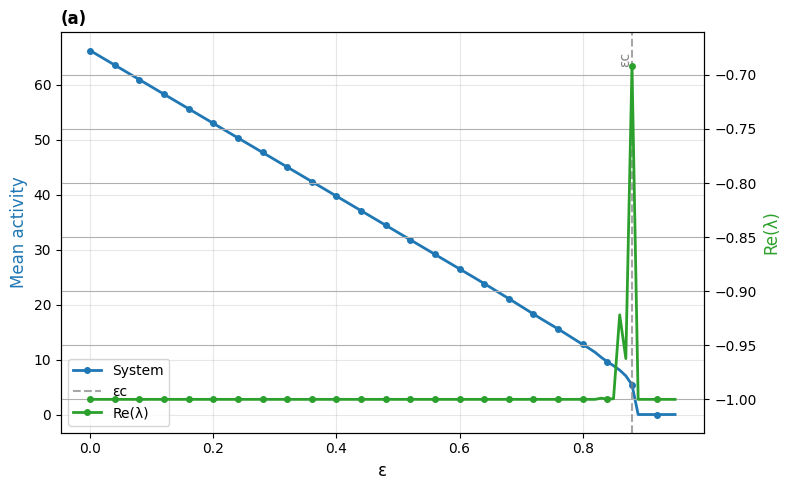

In [51]:
# Visualization: Match Figure 4(a) from PRX paper
# Plot (a): Mean activity and Re(λ) vs ε with circular markers

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Plot with circular markers to match paper
ax1.plot(plot_eps, plot_mean_activity, 'o-', color="tab:blue", label="System", 
         linewidth=2, markersize=4, markevery=max(1, len(plot_eps)//20))
ax2.plot(plot_eps, plot_dom_eig_real, 'o-', color="tab:green", label="Re(λ)", 
         linewidth=2, markersize=4, markevery=max(1, len(plot_eps)//20))

ax1.set_xlabel("ε", fontsize=12)
ax1.set_ylabel("Mean activity", color="tab:blue", fontsize=12)
ax2.set_ylabel("Re(λ)", color="tab:green", fontsize=12)

# Fix y-axis scaling - match paper ranges as closely as possible
#ax1.set_ylim(0.0, 1.0)
# For Re(λ), set appropriate range based on data
if len(plot_dom_eig_real) > 0:
    re_lambda_min = np.min(plot_dom_eig_real)
    re_lambda_max = np.max(plot_dom_eig_real)
    # Add some margin
    re_lambda_range = re_lambda_max - re_lambda_min
    if re_lambda_range > 0:
        ax2.set_ylim(re_lambda_min - 0.1*re_lambda_range, re_lambda_max + 0.1*re_lambda_range)
    else:
        ax2.margins(y=0.1)

# Tipping point line - gray dashed to match paper
if eps_c is not None:
    ax1.axvline(eps_c, color="gray", linestyle="--", alpha=0.7, linewidth=1.5, label="εc")
    ax1.text(eps_c, ax1.get_ylim()[1]*0.95, f"εc", rotation=90,
             va="top", ha="right", fontsize=10, color="gray")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=10)

# Grid
ax1.grid(True, alpha=0.3)

plt.title("(a)", fontsize=12, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()


In [58]:
# --- Main Public Function ---

def _sigmoid(x, tau, mu):
    """Logistic sigmoid: 1/(1 + e^(-τ(x - μ)))"""
    arg = -tau * (x - mu)
    return 1.0 / (1.0 + np.exp(np.clip(arg, -500, 500)))

def _sigmoid_derivative(x, tau, mu):
    """Derivative of logistic sigmoid."""
    s = _sigmoid(x, tau, mu)
    return tau * s * (1.0 - s)

def _rhs(x, epsilon, W_sparse, N, tau, mu):
    """Wilson-Cowan ODE: dx/dt = -x + Σ_j w_ij(1-ε) * sigmoid(x_j)"""
    weighted_input = (1.0 - epsilon) * (W_sparse @ _sigmoid(x, tau, mu))
    return -x + weighted_input

def _jacobian(x, epsilon, W_sparse, N, tau, mu):
    """Jacobian J = -I + (1-ε) * W @ diag(S'(x))"""
    sigmoid_deriv = _sigmoid_derivative(x, tau, mu)
    D = sp.diags(sigmoid_deriv, format="csr")
    I = sp.eye(N, format="csr")
    J = -I + (1.0 - epsilon) * (W_sparse @ D)
    return J

def _dominant_eig_real_part(J, N):
    """Compute real part of dominant (largest real part) eigenvalue."""
    try:
        vals = spla.eigs(J, k=1, which="LR", return_eigenvectors=False)
        return float(np.real(vals[0]))
    except Exception:
        try:
            J_dense = J.toarray()
            vals = npl.eigvals(J_dense)
            return float(np.max(np.real(vals)))
        except Exception:
            return np.nan

def _relax_to_steady_state(epsilon, x0, W_sparse, N, tau, mu, max_iter, dt, abs_tol):
    """Relax to steady state using explicit Euler integration."""
    x = x0.copy()
    _rhs_args = (epsilon, W_sparse, N, tau, mu) # Pre-pack args
    
    for _ in range(max_iter):
        dx = _rhs(x, *(_rhs_args))
        x_new = x + dt * dx
        np.clip(x_new, 0.0, None, out=x_new)
        if npl.norm(x_new - x) < abs_tol:
            return x_new
        x = x_new
    return x # Return last state if no convergence

def run_single_universe(rng, N_val, k_val, tau_val, mu_val, 
                        epsilon_step=0.01, max_iter=50000, dt=0.01, abs_tol=1e-8):
    """
    Generates one random network and runs a full epsilon sweep on it.
    
    This function corresponds to generating one "universe" as described
    in the paper (Sec III C):
    - N is randomly chosen
    - k (mean_degree) is randomly chosen
    - A new ER network with random weights is generated
    - A full sweep from eps=0 to 1 is performed.
    
    Returns:
        A dictionary containing the simulation results and the critical epsilon.
    """
    
    # --- 1. Generate the Network ---
    p_er = k_val / N_val
    G = nx.erdos_renyi_graph(n=N_val, p=p_er, seed=rng, directed=True)
    
    W = np.zeros((N_val, N_val))
    weight_min, weight_max = 10.0, 20.0
    for (i, j) in G.edges():
        W[i, j] = rng.uniform(weight_min, weight_max)
    W_sparse = sp.csr_matrix(W, dtype=float)

    # --- 2. Setup Simulation ---
    epsilon_min, epsilon_max = 0.0, 1.0
    epsilon_values = np.arange(epsilon_min, epsilon_max + epsilon_step, epsilon_step)
    num_eps = len(epsilon_values)
    mean_activity = np.zeros_like(epsilon_values)
    
    # Arguments for helper functions
    relax_args = (W_sparse, N_val, tau_val, mu_val, max_iter, dt, abs_tol)
    jacob_args = (W_sparse, N_val, tau_val, mu_val)

    # --- 3. Find Initial Bistable States ---
    x_init_low = rng.uniform(low=0.0, high=0.01, size=N_val)
    x_init_high = rng.uniform(low=50.0, high=80.0, size=N_val)
    
    x_low_0 = _relax_to_steady_state(0.0, x_init_low, *relax_args)
    x_high_0 = _relax_to_steady_state(0.0, x_init_high, *relax_args)

    if np.mean(x_low_0) > (np.mean(x_high_0) - 1.0):
        # No bistability found
        return {
            'N': N_val, 'k': k_val, 'tau': tau_val, 'mu': mu_val, 
            'eps_c': np.nan, 'eps_values': epsilon_values, 'activity': mean_activity,
            'error': 'No bistability'
        }
        
    x_current = x_high_0.copy()
    transitioned = False
    transition_idx = None
    
    # --- 4. Run Epsilon Sweep ---
    for i, eps in enumerate(epsilon_values):
        if not transitioned:
            x_star = _relax_to_steady_state(eps, x_current, *relax_args)
            mean_activity[i] = float(np.mean(x_star))
            
            activity_jump = mean_activity[i] - mean_activity[i-1] if i > 0 else 0.0
            jump_threshold = -10.0
            
            if (i > 0 and activity_jump < jump_threshold): 
                transitioned = True
                transition_idx = i
                x_star_low = _relax_to_steady_state(eps, x_low_0, *relax_args) 
                x_star = x_star_low.copy()
                mean_activity[i] = float(np.mean(x_star))
                x_current = x_star_low.copy()
            else:
                x_current = x_star.copy()
        else:
            x_star = _relax_to_steady_state(eps, x_current, *relax_args)
            mean_activity[i] = float(np.mean(x_star))
            x_current = x_star.copy()
            
    # --- 5. Find Critical Epsilon (eps_c) ---
    eps_c = np.nan
    idx_cross = None
    min_jump = 0.0
    jump_threshold = -5.0

    if transitioned:
        idx_cross = transition_idx
    else:
        for i in range(1, len(mean_activity)):
            jump = mean_activity[i] - mean_activity[i-1]
            if jump < min_jump and jump < jump_threshold:
                min_jump = jump
                idx_cross = i
                break
    
    if idx_cross is not None:
        eps_c = epsilon_values[idx_cross]
        
    return {
        'N': N_val, 'k': k_val, 'tau': tau_val, 'mu': mu_val, 
        'eps_c': eps_c, 'eps_values': epsilon_values, 'activity': mean_activity,
        'error': None
    }

## Model Description (Matching Paper Exactly)

The Wilson-Cowan model exhibits **first-order (explosive) transitions**:

- **System**: Each node has activity `x_i` with dynamics:
  - `dx_i/dt = -x_i + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))`
  - The logistic sigmoid creates nonlinearity and bistability
  - `(1-ε)` multiplies weights (link degradation)

- **Network**: Erdős-Rényi (ER) network
  - Mean degree: 3-6
  - Edge weights: random between 10-20
  - Directed network

- **Bistability**: The model has two stable fixed points:
  - **High-activity state** (functional): neurons active, system stable
  - **Low-activity state** (dysfunctional): neurons inactive, system stable

- **First-order transition**: At a critical `ε_c`, the system jumps from the high-activity to low-activity state.
  - This is a first-order (explosive) transition, not gradual
  - Both Mean activity and Re(λ) stay constant until `ε_c`, then jump sharply

- **Stability**: The Jacobian is `J = -I + (1-ε) * diag(S') * W`.
  - When `Re(λ_max(J)) < 0`: system is stable
  - When `Re(λ_max(J)) = 0`: critical point (tipping)
  - When `Re(λ_max(J)) > 0`: system is unstable (transitions to low-activity state)

This matches the PRX paper's Figure 4(a) behavior where both curves stay constant until the critical point, then jump.


# Wilson-Cowan Ensemble Simulation (Paper Reproduction)

This notebook runs multiple simulations ("universes") to reproduce the statistical results of the PRX paper. It is split into two parts:

1.  **Network Parameter Study:** Runs many simulations where `N` (network size) and `k` (mean degree) are varied, as described in the paper. This lets us see how the network structure affects the tipping point $\epsilon_c$.
2.  **Model Parameter Study:** Runs a grid of simulations where `tau` (steepness) and `mu` (threshold) are varied, to see how the model's core "physics" affect $\epsilon_c$.

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import random


# Set base parameters for all simulations
DEFAULT_TAU = 8.0
DEFAULT_MU = 4.0
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print("Imports and simulator loaded.")

Imports and simulator loaded.


## Part 1: Network Parameter Study (Varying N and k)

Here, we run many simulations (universes). In each, `tau` and `mu` are fixed, but we randomly pick `N` and `k` from the ranges specified in the paper (N: 300-700, k: 3-6).

In [60]:
# TODO: Change this to 1000 for the full paper analysis. 
# Set to 50 for a quick demonstration.
NUM_SIMULATIONS = 50

network_param_results = []
print(f"Running {NUM_SIMULATIONS} simulations (universes)...")

for i in tqdm(range(NUM_SIMULATIONS)):
    # Paper: N randomly between 300-700
    N_val = rng.integers(300, 701)
    # Paper: mean degree 3-6
    k_val = rng.uniform(3.0, 6.0)
    
    # Use a new seed for each run based on the main seed
    sim_rng = np.random.default_rng(RNG_SEED + i)
    
    result = run_single_universe(sim_rng, N_val, k_val, DEFAULT_TAU, DEFAULT_MU)
    network_param_results.append(result)

print(f"Simulation complete. {len(network_param_results)} results collected.")

# Convert results to a DataFrame for easier plotting
df_network = pd.DataFrame(network_param_results)
df_network = df_network.dropna(subset=['eps_c']) # Drop any runs that failed

print(f"{len(df_network)} simulations successfully found a tipping point.")
df_network.head()

Running 50 simulations (universes)...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [02:39<00:00,  3.19s/it]

Simulation complete. 50 results collected.
45 simulations successfully found a tipping point.


,N,k,tau,mu,eps_c,eps_values,activity,error
0,335,4.316635,8.0,4.0,0.88,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[66.49149753701923, 65.8265826070208, 65.16166...",None
1,610,5.575794,8.0,4.0,0.91,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[82.99617204753821, 82.16621038212605, 81.3362...",None
2,334,3.282532,8.0,4.0,0.83,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[45.33022147236631, 44.876919292332694, 44.423...",None
3,579,5.926867,8.0,4.0,0.91,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[88.30548977152688, 87.42243492407515, 86.5393...",None
4,595,5.358193,8.0,4.0,0.91,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[78.45110623945536, 77.66659521914242, 76.8820...",None


### Plot 1: Mean Activity for 4 Random Universes

This plot shows the `mean activity vs. epsilon` for 4 random universes from the set we just generated. As you requested, this clearly shows that the **critical epsilon ($\epsilon_c$) varies** for each network.

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_459172/1420637765.py:9: SyntaxWarning: invalid escape sequence '\e'
  label = f"N={res['N']}, k={res['k']:.1f}, $\epsilon_c$={res['eps_c']:.2f}"
/tmp/ipykernel_459172/1420637765.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\epsilon$ (Link Degradation)", fontsize=12)
/tmp/ipykernel_459172/1420637765.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Mean Activity ($\overline{x}$)", fontsize=12)


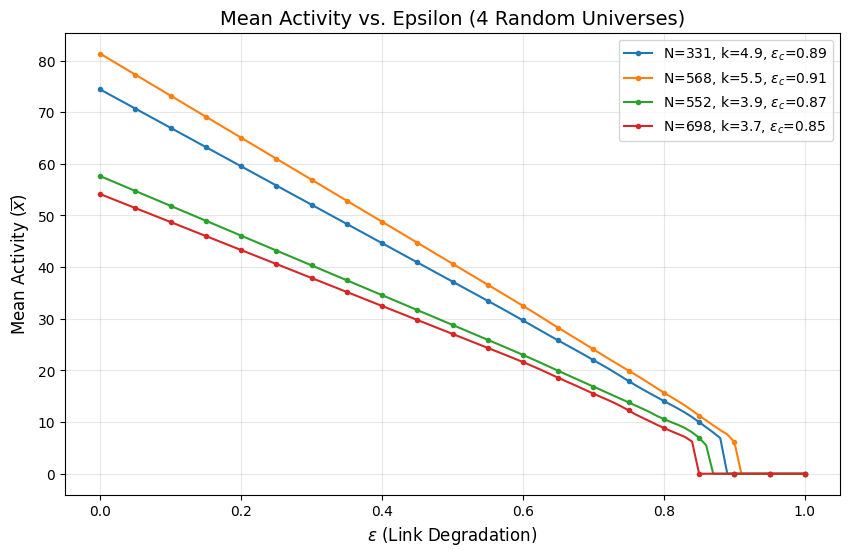

In [61]:
if len(df_network) >= 4:
    plt.figure(figsize=(10, 6))
    
    # Select 4 random simulations to plot
    random_indices = df_network.sample(n=4, random_state=RNG_SEED).index
    
    for idx in random_indices:
        res = df_network.loc[idx]
        label = f"N={res['N']}, k={res['k']:.1f}, $\epsilon_c$={res['eps_c']:.2f}"
        plt.plot(res['eps_values'], res['activity'], 'o-', label=label, markersize=3, markevery=5)
    
    plt.title(f"Mean Activity vs. Epsilon (4 Random Universes)", fontsize=14)
    plt.xlabel("$\epsilon$ (Link Degradation)", fontsize=12)
    plt.ylabel("Mean Activity ($\overline{x}$)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Not enough simulation results to plot. Try running more simulations.")

### Plot 2: Critical Epsilon vs. Network Hyperparameters

This plot shows how the tipping point $\epsilon_c$ (y-axis) is affected by the network size `N` (x-axis) and the mean degree `k` (dot size/color).

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_459172/3765003171.py:16: SyntaxWarning: invalid escape sequence '\e'
  g.set_axis_labels("Network Size (N)", "Critical Epsilon ($\epsilon_c$)")


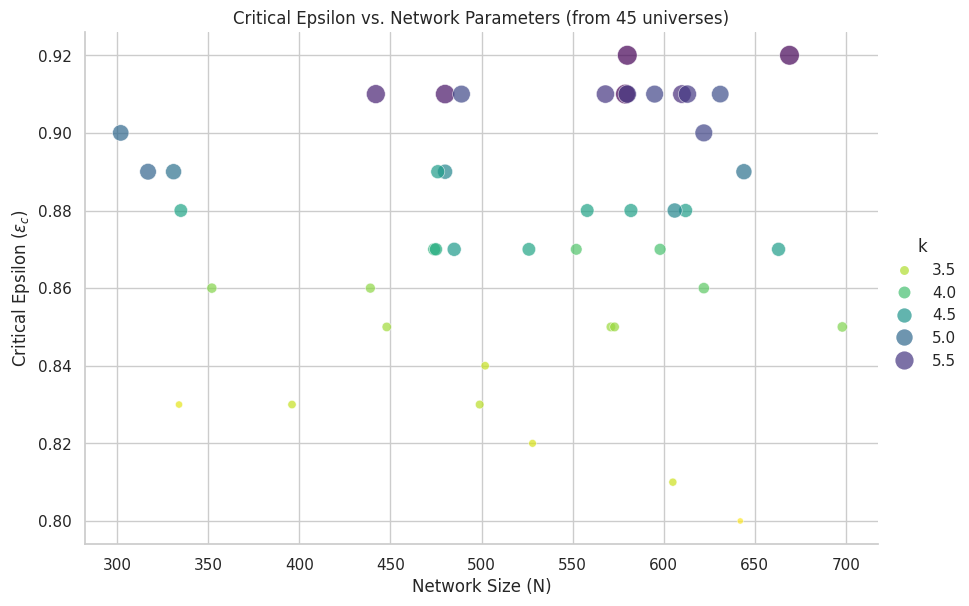

In [62]:
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df_network,
    x="N", 
    y="eps_c",
    hue="k", 
    size="k",
    palette="viridis_r", 
    sizes=(20, 200),
    alpha=0.7,
    height=6,
    aspect=1.5
)

g.set_axis_labels("Network Size (N)", "Critical Epsilon ($\epsilon_c$)")
g.ax.set_title(f"Critical Epsilon vs. Network Parameters (from {len(df_network)} universes)")
plt.show()

## Part 2: Model Parameter Study (Varying τ and μ)

Now we do the reverse. We keep the network **fixed** (`N=300`, `k=4.5`) and instead vary the model's core parameters, `tau` and `mu`, to see how they influence the tipping point.

In [63]:
# Use the fixed network parameters from our original successful run
FIXED_N = 300
FIXED_K = 4.5

# TODO: Increase steps (e.g., 10) for a high-resolution heatmap.
# Set to 5 for a quick 5x5 grid (25 simulations).
N_STEPS = 5 
tau_range = np.linspace(6.0, 10.0, N_STEPS)
mu_range = np.linspace(3.0, 5.0, N_STEPS)

model_param_results = []
total_sims = len(tau_range) * len(mu_range)
print(f"Running {total_sims} simulations for model parameter sweep...")

# We can use the same RNG seed for the network generation every time
# This ensures we are testing all (tau, mu) pairs on the *exact same network*
sim_rng = np.random.default_rng(RNG_SEED)

for tau_val in tqdm(tau_range):
    for mu_val in mu_range:
        # Pass the *same* sim_rng seed each time to generate the same network
        result = run_single_universe(sim_rng, FIXED_N, FIXED_K, tau_val, mu_val)
        model_param_results.append(result)

print("Model parameter sweep complete.")

# Convert to DataFrame
df_model = pd.DataFrame(model_param_results)
df_model.head()

Running 25 simulations for model parameter sweep...


100%|██████████| 5/5 [01:06<00:00, 13.37s/it]

Model parameter sweep complete.


,N,k,tau,mu,eps_c,eps_values,activity,error
0,300,4.5,6.0,3.0,NaN,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[67.90041975680734, 67.22141560463623, 66.5424...",None
1,300,4.5,6.0,3.5,0.90,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[69.2498820794055, 68.55738330219084, 67.86488...",None
2,300,4.5,6.0,4.0,0.88,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[64.27710320891349, 63.63433221346209, 62.9915...",None
3,300,4.5,6.0,4.5,0.86,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[63.92745704282749, 63.28818251415233, 62.6489...",None
4,300,4.5,6.0,5.0,0.85,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[65.06492102644319, 64.4142718530276, 63.76362...",None


### Plot 3: Critical Epsilon vs. Model Hyperparameters (τ and μ)

This heatmap shows the result. 

* **Y-axis ($\tau$):** As steepness `tau` increases (goes up), the transition becomes more abrupt, but the tipping point $\epsilon_c$ doesn't change much in this range.
* **X-axis ($\mu$):** As the firing threshold `mu` increases (goes right), the neurons are "harder to activate," so the network is weaker. This means it **collapses much earlier** (i.e., $\epsilon_c$ is lower).

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_459172/1099948479.py:11: SyntaxWarning: invalid escape sequence '\e'
  cbar_kws={'label': 'Critical Epsilon ($\epsilon_c$)'}
/tmp/ipykernel_459172/1099948479.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"Critical Epsilon ($\epsilon_c$) vs. Model Parameters (N={FIXED_N}, k={FIXED_K:.1f})")


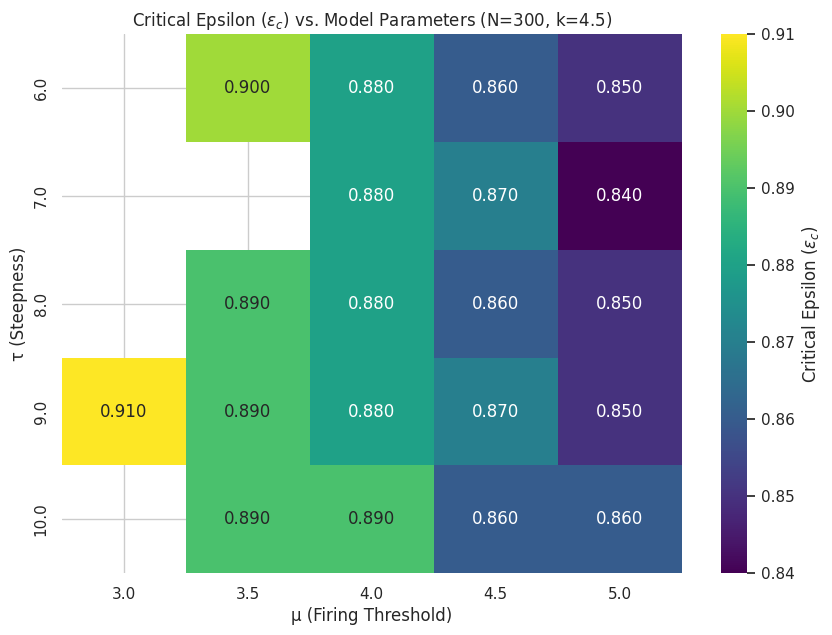

In [64]:
if not df_model.empty:
    # Pivot the data to create a 2D grid for the heatmap
    try:
        df_pivot = df_model.pivot(index="tau", columns="mu", values="eps_c")
        plt.figure(figsize=(10, 7))
        sns.heatmap(
            df_pivot, 
            annot=True, 
            fmt=".3f", 
            cmap="viridis",
            cbar_kws={'label': 'Critical Epsilon ($\epsilon_c$)'}
        )
        plt.title(f"Critical Epsilon ($\epsilon_c$) vs. Model Parameters (N={FIXED_N}, k={FIXED_K:.1f})")
        plt.xlabel("μ (Firing Threshold)")
        plt.ylabel("τ (Steepness)")
        plt.show()
    except Exception as e:
        print(f"Could not pivot data for heatmap. Error: {e}")
        print("Displaying raw data instead:")
        print(df_model[['tau', 'mu', 'eps_c']])
else:
    print("No data collected for model parameter sweep.")